# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

## **ANÁLISIS DESCRIPTIVO DE DATOS**

In [119]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

**2. Selección del dataset:**

In [69]:
# Import dataset
df_penguins = sns.load_dataset('penguins') #  Se considera una alternativa moderna y más diversa al dataset iris.

**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.


In [70]:
# Mostrar propiedades de la tabla
df_penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [75]:
# Mostrar las 5 primeras filas
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Interpretación**

 El dataset ha sido cargado correctamente, que tiene 344 registros, 7 columnas de las cuales, 4 son númericas y 3 del tipo objeto, probablemente tengamos campos vacíos. Las 3 variables de tipo objeto son categóricas.

In [71]:
# Realizar un recuento de datos vacios en el dataset
df_penguins.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


**Interpretación**

Confirmamos la existencia de valores faltantes, sobre todo en el apartado de sexo con 11, algo a tener en consideración si es que nuestras dudas van orientadas al análisis de esta característica y su relación con otras.

In [97]:
# Eliminar del dataset los registros que tienen características faltantes
df_penguins.dropna(inplace=True)
print(df_penguins.info())

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB
None


**Interpretación**

Derivado de una pequeña limpieza de los nulos, nos percatamos que pasamos de 344 a 333 entradas completas.

In [103]:
# Revisar valores únicos en las categorías no numéricas
print(df_penguins['island'].value_counts())
print()
print(df_penguins['species'].value_counts())
print()
print(df_penguins['sex'].value_counts())

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

sex
Male      168
Female    165
Name: count, dtype: int64


**Interpretación**

Las mediciones corresponden a tres especies de pingüinos, realizadas en tres islas, y contienen números no distantes de ejemplares másculinos y femeninos. No contiene errores tipográficos al momento de realizar la captura ya que hay distinciones claras en las entradas registradas.

In [74]:
# Mostrar resumen estadístico
df_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


**Interpretación**

Podemos observar que las variables numericas están en orden ya que no tienen desviaciones estándar enormes respecto de lo que podríamos esperar de especies pertenecientes a pingüinos y que fueron realizadas correctamente las mediciones, ya que los valores máximos y mínimos están cerca de su media.

### Medidas de tendencia central

In [76]:
# Definir medidas de tendencia central por especie
promedio_penguins = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()
mediana_penguins = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].median()
moda_penguins = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].apply(lambda x: x.mode().iloc[0])

print("Promedio:")
print(promedio_penguins)
print("\nMediana:")
print(mediana_penguins)
print("\nModa:")
print(moda_penguins)

Promedio:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.823973      18.347260         190.102740  3706.164384
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.568067      14.996639         217.235294  5092.436975

Mediana:
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie              38.85          18.40              190.0       3700.0
Chinstrap           49.55          18.45              196.0       3700.0
Gentoo              47.40          15.00              216.0       5050.0

Moda:
0          bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie               41.1           18.5              190.0       3550.0
Chinstrap            51.

**Interpretación**

Las 3 especies tienen valores adecuados, no hay outliers, que puedan generar un ruido significativo, debido a que sus medias aritméticas son cercanas a su mediana. Los valores como la moda se podrán interpretar de mejor forma cuando obtengamos la frecuencia de cada uno de estos valores, comparada con la de los demás.

### Medidas de dispersión

In [107]:
# Definir medidas de dispersión por especie
std_dev_penguins = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].std()
var_penguins = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].var()
rango = df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].max() - df_penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].min()


print("Desviación Estándar: \n")
print(std_dev_penguins)
print("-"*80)
print("\nVarianza: \n")
print(var_penguins)
print("-"*80)
print("\n Rango: \n")
print(rango)


Desviación Estándar: 

           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie           2.662597       1.219338           6.521825   458.620135
Chinstrap        3.339256       1.135395           7.131894   384.335081
Gentoo           3.106116       0.985998           6.585431   501.476154
--------------------------------------------------------------------------------

Varianza: 

           bill_length_mm  bill_depth_mm  flipper_length_mm    body_mass_g
species                                                                   
Adelie           7.089421       1.486786          42.534199  210332.427964
Chinstrap       11.150630       1.289122          50.863916  147713.454785
Gentoo           9.647955       0.972192          43.367896  251478.332859
--------------------------------------------------------------------------------

 Rango: 

           bill_length_mm  bill_depth_mm  flipper_l

**Interpretación**

Las medidas de los picos, en largo y ancho tienen muy poca variabilidad, comparadas con el largo de la aleta y su peso.

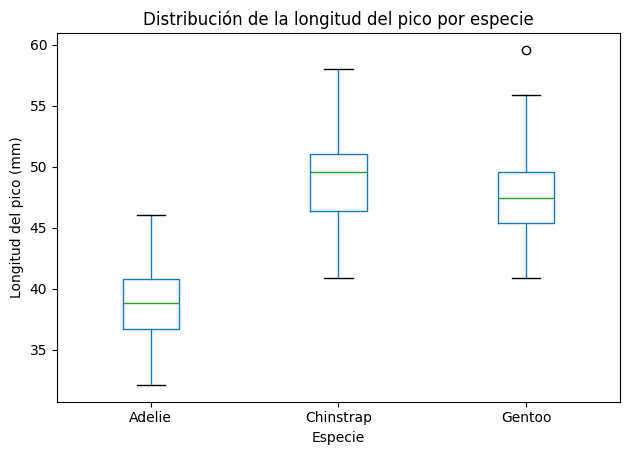

In [78]:
# Visualizar longitud de pico por especie

df_penguins.boxplot(column='bill_length_mm', by='species', grid=False)
plt.suptitle('')  # quita título automático
plt.title('Distribución de la longitud del pico por especie')
plt.xlabel('Especie')
plt.ylabel('Longitud del pico (mm)')
plt.tight_layout()
plt.show()

**Interpretación**

La especie Chisntrap tiene el pico más largo, seguida de la Gentoo por muy poco y aunque se solapen en algunos casos, la especie Adelie será la que tenga el pico más pequeño.

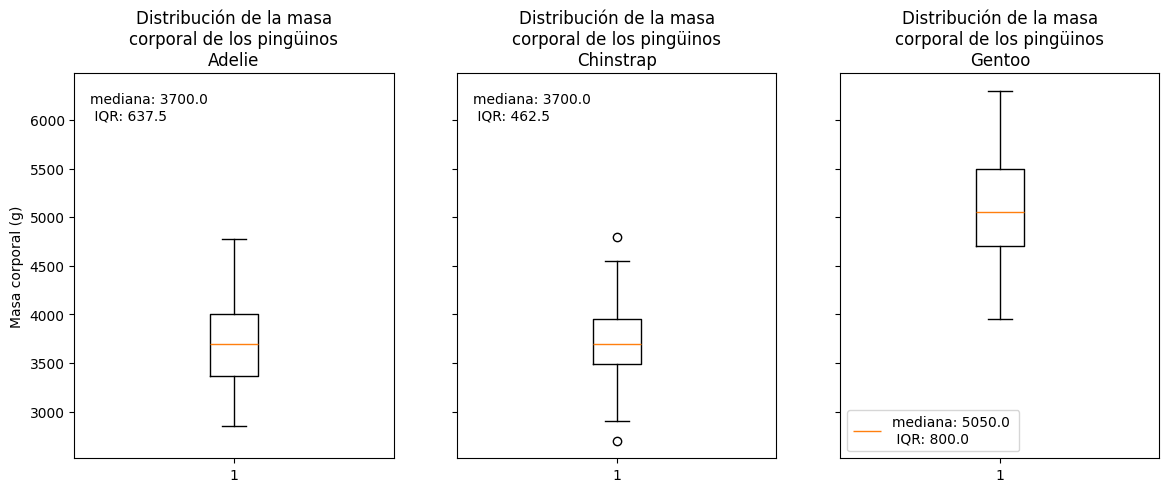

In [132]:
# Percentiles

# Calcular percentiles para Adelie
percentil = np.percentile(df_penguins['body_mass_g'][df_penguins['species']== 'Adelie'], [25, 50, 75])
q_1a = round(percentil[0], 2)
q_3a = round(percentil[2], 2)
iqra = round(q_3a - q_1a, 2)

#Calcular percentiles para Chinstrap
percentil = np.percentile(df_penguins['body_mass_g'][df_penguins['species']== 'Chinstrap'], [25, 50, 75])
q_1c = round(percentil[0], 2)
q_3c = round(percentil[2], 2)
iqrc = round(q_3c - q_1c, 2)

#Calcular percentiles para Gentoo
percentil = np.percentile(df_penguins['body_mass_g'][df_penguins['species']== 'Gentoo'], [25, 50, 75])
q_1g = round(percentil[0], 2)
q_3g = round(percentil[2], 2)
iqrg = round(q_3g - q_1g, 2)

# Visualizar percentiles
fig, axes = plt.subplots(1,3, figsize = (14,5), sharey=True)

axes[0].boxplot(df_penguins['body_mass_g'][df_penguins['species']== 'Adelie'])
axes[0].text(0.05, 0.95, f'mediana: {round(df_penguins["body_mass_g"][df_penguins["species"]=="Adelie"].median(), 2)} \n IQR: {iqra}', transform=axes[0].transAxes, va='top')
titulo = 'Distribución de la masa corporal de los pingüinos Adelie'
titulo_envuelto = textwrap.fill(titulo, width=30)
axes[0].set_title(titulo_envuelto)
axes[0].set_ylabel('Masa corporal (g)')

axes[1].boxplot(df_penguins['body_mass_g'][df_penguins['species']== 'Chinstrap'])
axes[1].text(0.05, 0.95, f'mediana: {round(df_penguins["body_mass_g"][df_penguins["species"]=="Chinstrap"].median(), 2)} \n IQR: {iqrc}', transform=axes[1].transAxes, va='top')

titulo1 = 'Distribución de la masa corporal de los pingüinos Chinstrap'
titulo_envuelto1 = textwrap.fill(titulo1, width=30)
axes[1].set_title(titulo_envuelto1)

axes[2].boxplot(df_penguins['body_mass_g'][df_penguins['species']== 'Gentoo'], label= f'mediana: {round(df_penguins["body_mass_g"][df_penguins["species"]=="Gentoo"].median(), 2)} \n IQR: {iqrg}')

titulo2 = 'Distribución de la masa corporal de los pingüinos Gentoo'
titulo_envuelto2 = textwrap.fill(titulo2, width=30)
axes[2].set_title(titulo_envuelto2)

plt.legend()
plt.show()

**Interpretación**

El 50% central de los pinguinos chinstrap pesa entre 3847 y 3950 g.

El peso típico de un chinstrap es de 3700 g. Similar a Adelie pero combinandolo con la longitud del pico podríamos inferir de que especie se trata.

El peso de los pingüinos Chinstrap varía menos que la especie Adelie y no es tan variable como la Gentoo.

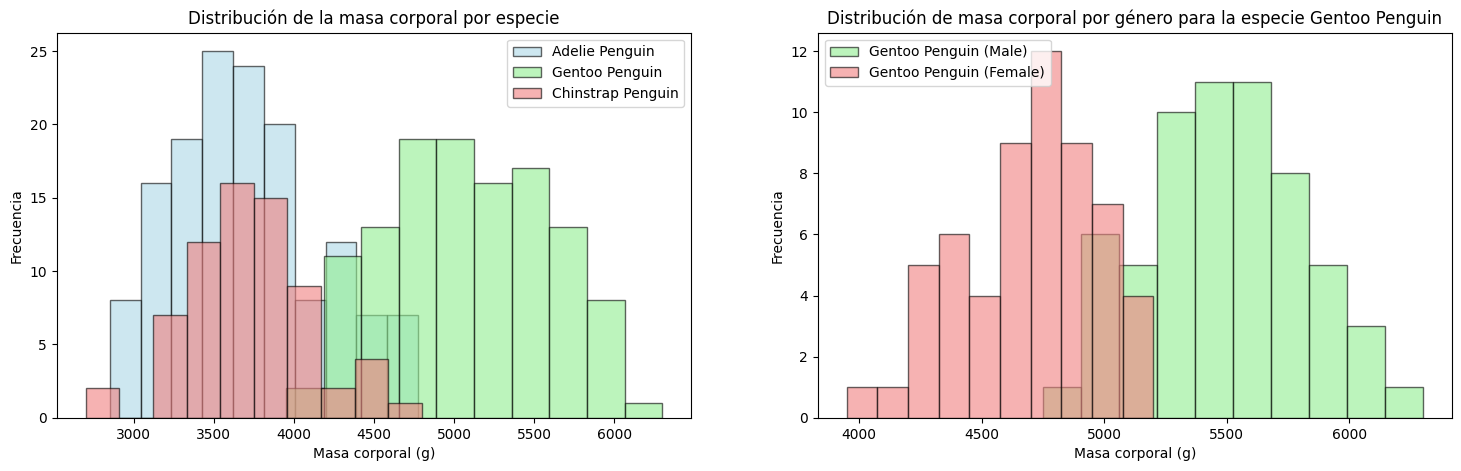

In [79]:
# Visualizar distribución de la masa corporal por especie y sexo
fig, axes = plt.subplots(1,2, figsize = (18,5))

# GRAFICO 1 Distribución de la masa corporal por especie usando un histograma

# Graficar distribución de masa corporal para Adelie Penguin
axes[0].hist(df_penguins[df_penguins['species'] == 'Adelie']['body_mass_g'], edgecolor='black', color='lightblue', label='Adelie Penguin', alpha=.6)
# Graficar distribución de masa corporal para Gentoo Penguin
axes[0].hist(df_penguins[df_penguins['species'] == 'Gentoo']['body_mass_g'], edgecolor='black', color='lightgreen', label='Gentoo Penguin', alpha=.6)
# Graficar distribución de masa corporal para Chinstrap Penguin
axes[0].hist(df_penguins[df_penguins['species'] == 'Chinstrap']['body_mass_g'], edgecolor='black', color='lightcoral', label='Chinstrap Penguin', alpha=.6)

# Estilar gráfico para visualización
axes[0].set_title('Distribución de la masa corporal por especie')
axes[0].set_xlabel('Masa corporal (g)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# GRAFICO 2 Distribución de la masa corporal por sexo (Male Gentoo)

# Graficar distribución de masa corporal por sexo para Gentoo Penguin (Male)
axes[1].hist(df_penguins[(df_penguins['species'] == 'Gentoo') & (df_penguins['sex']== 'Male')]['body_mass_g'], edgecolor='black', color='lightgreen', label='Gentoo Penguin (Male)', alpha=.6)

# Graficar distribución de masa corporal por sexo para Gentoo Penguin (female)
axes[1].hist(df_penguins[(df_penguins['species'] == 'Gentoo') & (df_penguins['sex']== 'Female')]['body_mass_g'], edgecolor='black', color='lightcoral', label='Gentoo Penguin (Female)', alpha=.6)

# Estilar gráfico para visualización del segundo subplot
axes[1].set_title('Distribución de masa corporal por género para la especie Gentoo Penguin')
axes[1].set_xlabel('Masa corporal (g)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.show()

**Interpretación**

* La especie Gentoo tiene los ejemplares con mayor masa corporal.

* Hay una diferencia notoria entre los ejemplares masculinos y gemeninos de la especie Gentoo.

**5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

In [108]:
# Definir variables
columnas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df_penguins[columnas].corr() # Calcula la matriz de correlación de Pearson/ es un DataFrame de 4x4
long_col = len(columnas)

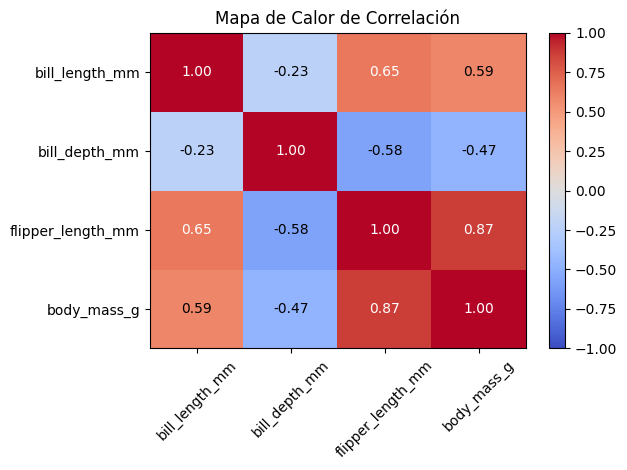

In [109]:
# Visualizar mapa de calor
corr_inv = corr.iloc[::-1]
heatmap = plt.pcolor(corr_inv, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Mapa de Calor de Correlación')
plt.xticks(np.arange(0.5, long_col, 1), columnas, rotation=45) # Se usa así para centrar las etiquetas
plt.yticks(np.arange(0.5, long_col, 1), columnas[::-1]) # Se invierte por que se invirtieron las filas de corr

for i in range(len(columnas)): # i es la Fila
    for j in range(len(columnas)): # j es la Columna
        val = round(corr_inv.iloc[i, j], 2) #Redondea a dos decimales y se guarda en val
        plt.text(j + 0.5, i + 0.5, f"{val:.2f}", # Escribe el número dentro de la celda
                 ha = 'center', va = 'center', # Centrado vertical y horizontal
                 color = 'white' if abs(val) > 0.6 else 'black') # Cambia el color en función de la correlación para facilitar la lectura

plt.colorbar(heatmap) # Agrega la barra lateral que dice qué color correspode a que valor de -1 a 1
plt.tight_layout() # Ajusta automáticamente los márgenes para que no se corten las etiquetas de los ejes ni el título
plt.show()

 **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 2 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 2 columnas.

In [133]:
# Definir variables
corr_flipper_body = round(df_penguins['flipper_length_mm'].corr(df_penguins['body_mass_g']), 2)
corr_flipper_bill = round(df_penguins['flipper_length_mm'].corr(df_penguins['bill_length_mm']), 2)

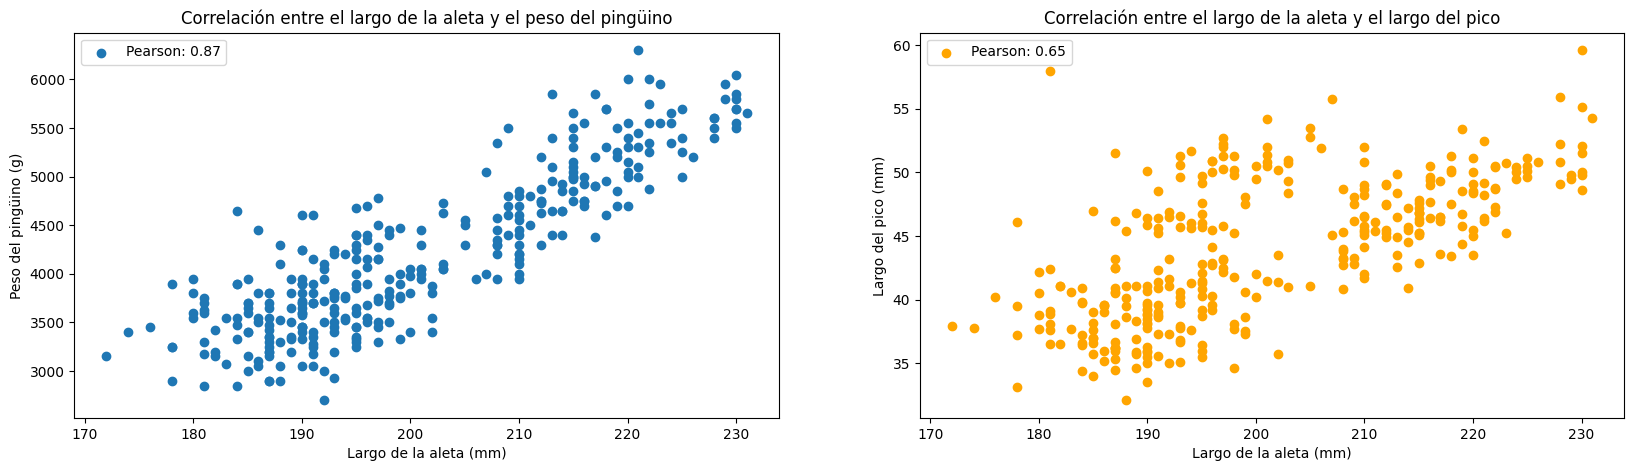

In [134]:
# Visualizar correlaciones
fig, ax = plt.subplots(1,2, figsize=(20,5))

ax[0].scatter(data = df_penguins, x = 'flipper_length_mm', y = 'body_mass_g', label=f"Pearson: {corr_flipper_body}")
ax[0].set_title('Correlación entre el largo de la aleta y el peso del pingüino')
ax[0].set_xlabel('Largo de la aleta (mm)')
ax[0].set_ylabel('Peso del pingüino (g)')
ax[0].legend()

ax[1].scatter(data = df_penguins, x = 'flipper_length_mm', y = 'bill_length_mm', label=f"Pearson: {corr_flipper_bill}", color="orange")
ax[1].set_title('Correlación entre el largo de la aleta y el largo del pico')
ax[1].set_xlabel('Largo de la aleta (mm)')
ax[1].set_ylabel('Largo del pico (mm)')
ax[1].legend()

plt.show()

**Interpretación**

Existe una correlación positiva fuerte r=0.87, donde la longitud del lago de la aleta explica el 75% de la variación en masa corporal.

Existe una correlación positiva moderada r = 0,65, donde la longitud de la aleta explica el 42% de la variación en el largo del pico.

## Aprendizaje estadístico

### Prueba de hipótesis

**Pregunta: ¿Podemos predecir el largo de su aleta conociendo su masa corporal?**

In [136]:
df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [141]:
# Definir regresión lineal
x = df_penguins['body_mass_g']
y = df_penguins['bill_length_mm']

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.0040032903204149295 x + 27.15072199884297


In [144]:
# Definir parámetros

tamaño_paso = 1e-9  # Reducir drásticamente el tamaño del paso
theta_0 = 0.004  # alfa de la ecuación de linea
theta_1 = 27.15  # beta de la ecuación de linea

perdida = []

n = len(x)

# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100000 # Aumentar el número de iteraciones para una mejor convergencia con un paso pequeño

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error = ((y_pred - y) ** 2).mean()
    perdida.append(error)

    d_theta_0 = (2 / n) * np.sum(y_pred - y)
    d_theta_1 = (2 / n) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamaño_paso * d_theta_0
    theta_1 = theta_1 - tamaño_paso * d_theta_1

print(f'y = {theta_1} x + {theta_0}')

y = 0.010229972739715392 x + -0.0020323549352021498


In [145]:
# Predicción de valores con descenso de gradiente
tb_pred_gd = float(input('Ingresa la masa corporal en gramos para predecir el tamaño de su aleta en mm: '))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'El tamaño de aleta será de {y_pred_gd} mm')

Ingresa la masa corporal en gramos para predecir el tamaño de su aleta en mm: 3750
El tamaño de aleta será de 38.36 mm


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

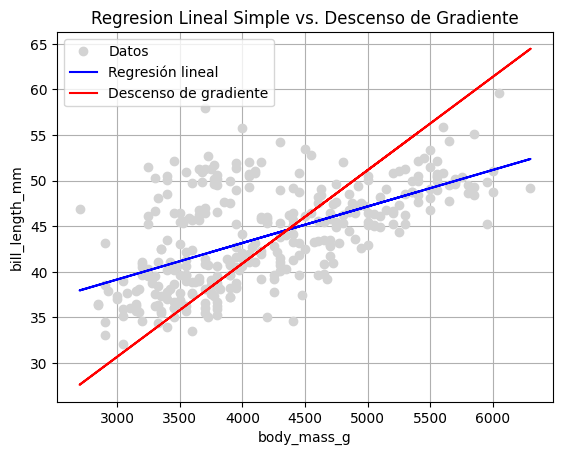

In [146]:
# Visualizar regresiones
plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta*x + alpha, color = 'blue', label = 'Regresión lineal')
plt.title("Regresion Lineal Simple vs. Descenso de Gradiente")
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Descenso de gradiente')
plt.xlabel('body_mass_g')
plt.ylabel('bill_length_mm')
plt.legend()
plt.grid()
plt.show()

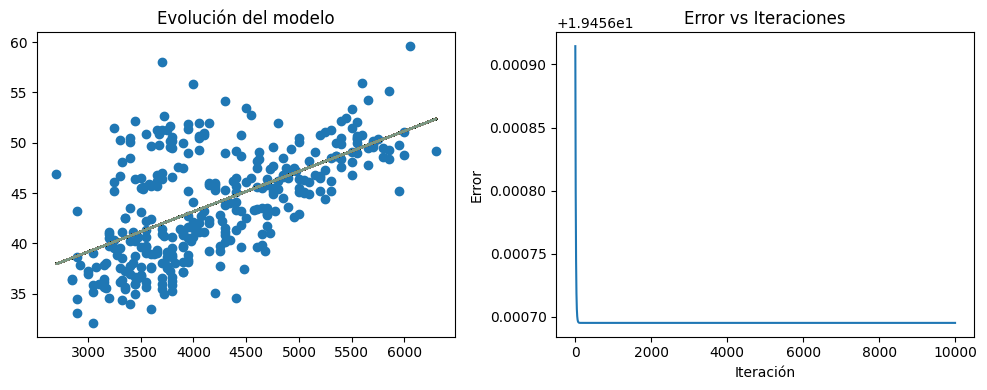

y = 0.0040 x + 27.1500  Error: 19.4567


In [150]:
# Visualizar función de costo

# 🔹 Parámetros iniciales
m = 0.004 # pendiente
b = 27.15 # intercepto
lr = 1e-9 # learning rate/ tasa de aprendizaje
epochs = 10000 # Número de iteraciones

# 🔹 Para guardar historia
errores = []
m_hist = []
b_hist = []

# 🔁 Entrenamiento
for _ in range(epochs):
    y_pred = m * x + b
    error = np.mean((y - y_pred)**2)

    errores.append(error)
    m_hist.append(m)
    b_hist.append(b)

    # Gradientes
    dm = (-2/len(x)) * np.sum(x * (y - y_pred))
    db = (-2/len(x)) * np.sum(y - y_pred)

    # Actualización
    m -= lr * dm
    b -= lr * db

# 📊 GRÁFICAS
plt.figure(figsize=(10,4))

# 🔹 Subplot 1: evolución de la recta
plt.subplot(1,2,1)
plt.scatter(x, y)

for i in range(len(m_hist)):
    plt.plot(x, m_hist[i]*x + b_hist[i], alpha=0.3)

plt.title("Evolución del modelo")

# 🔹 Subplot 2: error
plt.subplot(1,2,2)
plt.plot(errores)
plt.title("Error vs Iteraciones")
plt.xlabel("Iteración")
plt.ylabel("Error")

plt.tight_layout()
plt.show()

print(f'y = {m:.4f} x + {b:.4f}  Error: {errores[-1]:.4f}')

De lo anterior podemos concluir que podemos tener una buena aproximación si conocemos la masa para conocer el tamaño de la aleta ya que existe una fuerte correlación entre ambas variables.